In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_new_multishell_ball3stick_simformer6_v_pred")
graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, static, state)
model.eval()

In [4]:
sim_type = model.tokenizer.simulator

In [21]:
p_mask,masks, theta, x_os, acq, _ = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(1), num=200))

[ True  True  True  True  True]
[ 6.061  8.637  9.3   11.774 12.542 12.596 13.285 13.312 13.537 13.602
 14.854 15.246 15.327 15.449 16.096 16.234 16.285 16.632 16.644 17.13
 18.064 18.216 18.323 19.937 19.959 21.233 21.356 21.49  21.989 22.581
 23.042 23.244 23.963 24.033 24.607 24.793 25.876 26.409 27.01  27.95
 28.089 28.147 28.693 28.752 29.116 29.22  29.299 30.134 30.147 31.063
 32.807 33.035 33.245 33.423 33.648 34.508 34.92  35.117 35.322 36.096
 36.633 36.699 36.813 36.961 37.95  38.06  38.641 39.069 40.034 40.043
 40.297 40.661 41.103 41.12  41.334 41.408 41.457 41.599 41.715 41.955
 42.11  42.396 42.795 43.291 43.363 43.396 43.833 43.98  44.007 44.148
 44.897 45.3   45.632 45.703 46.227 46.36  46.6   46.631 46.678 47.286
 47.39  47.566 47.792 47.875 47.932]


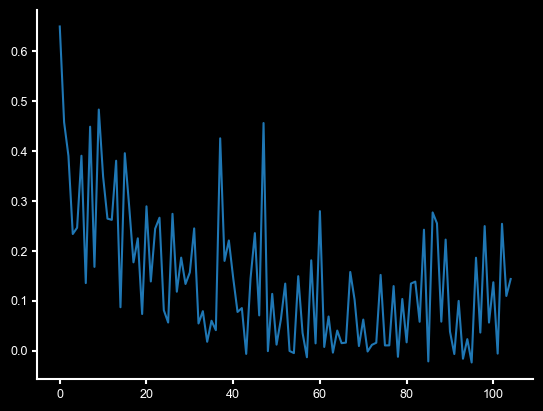

In [22]:
idx = 30
print(masks[idx])
print(acq.qvals[idx])
plt.plot(x_os[idx])

In [23]:
from functools import partial
sample_fn = jax.jit(jax.vmap(partial(model.sample_theta, num_steps=50, max_noise=80, model_mask=masks[idx], sample_method="ode", rho=7), in_axes=(0,None, None)))

In [24]:
# First run slow due to JIT compilation
thetas_post = sample_fn(jax.random.split(jax.random.key(0), 10_000), jax.tree_util.tree_map(lambda x: x[idx], acq), x_os[idx])

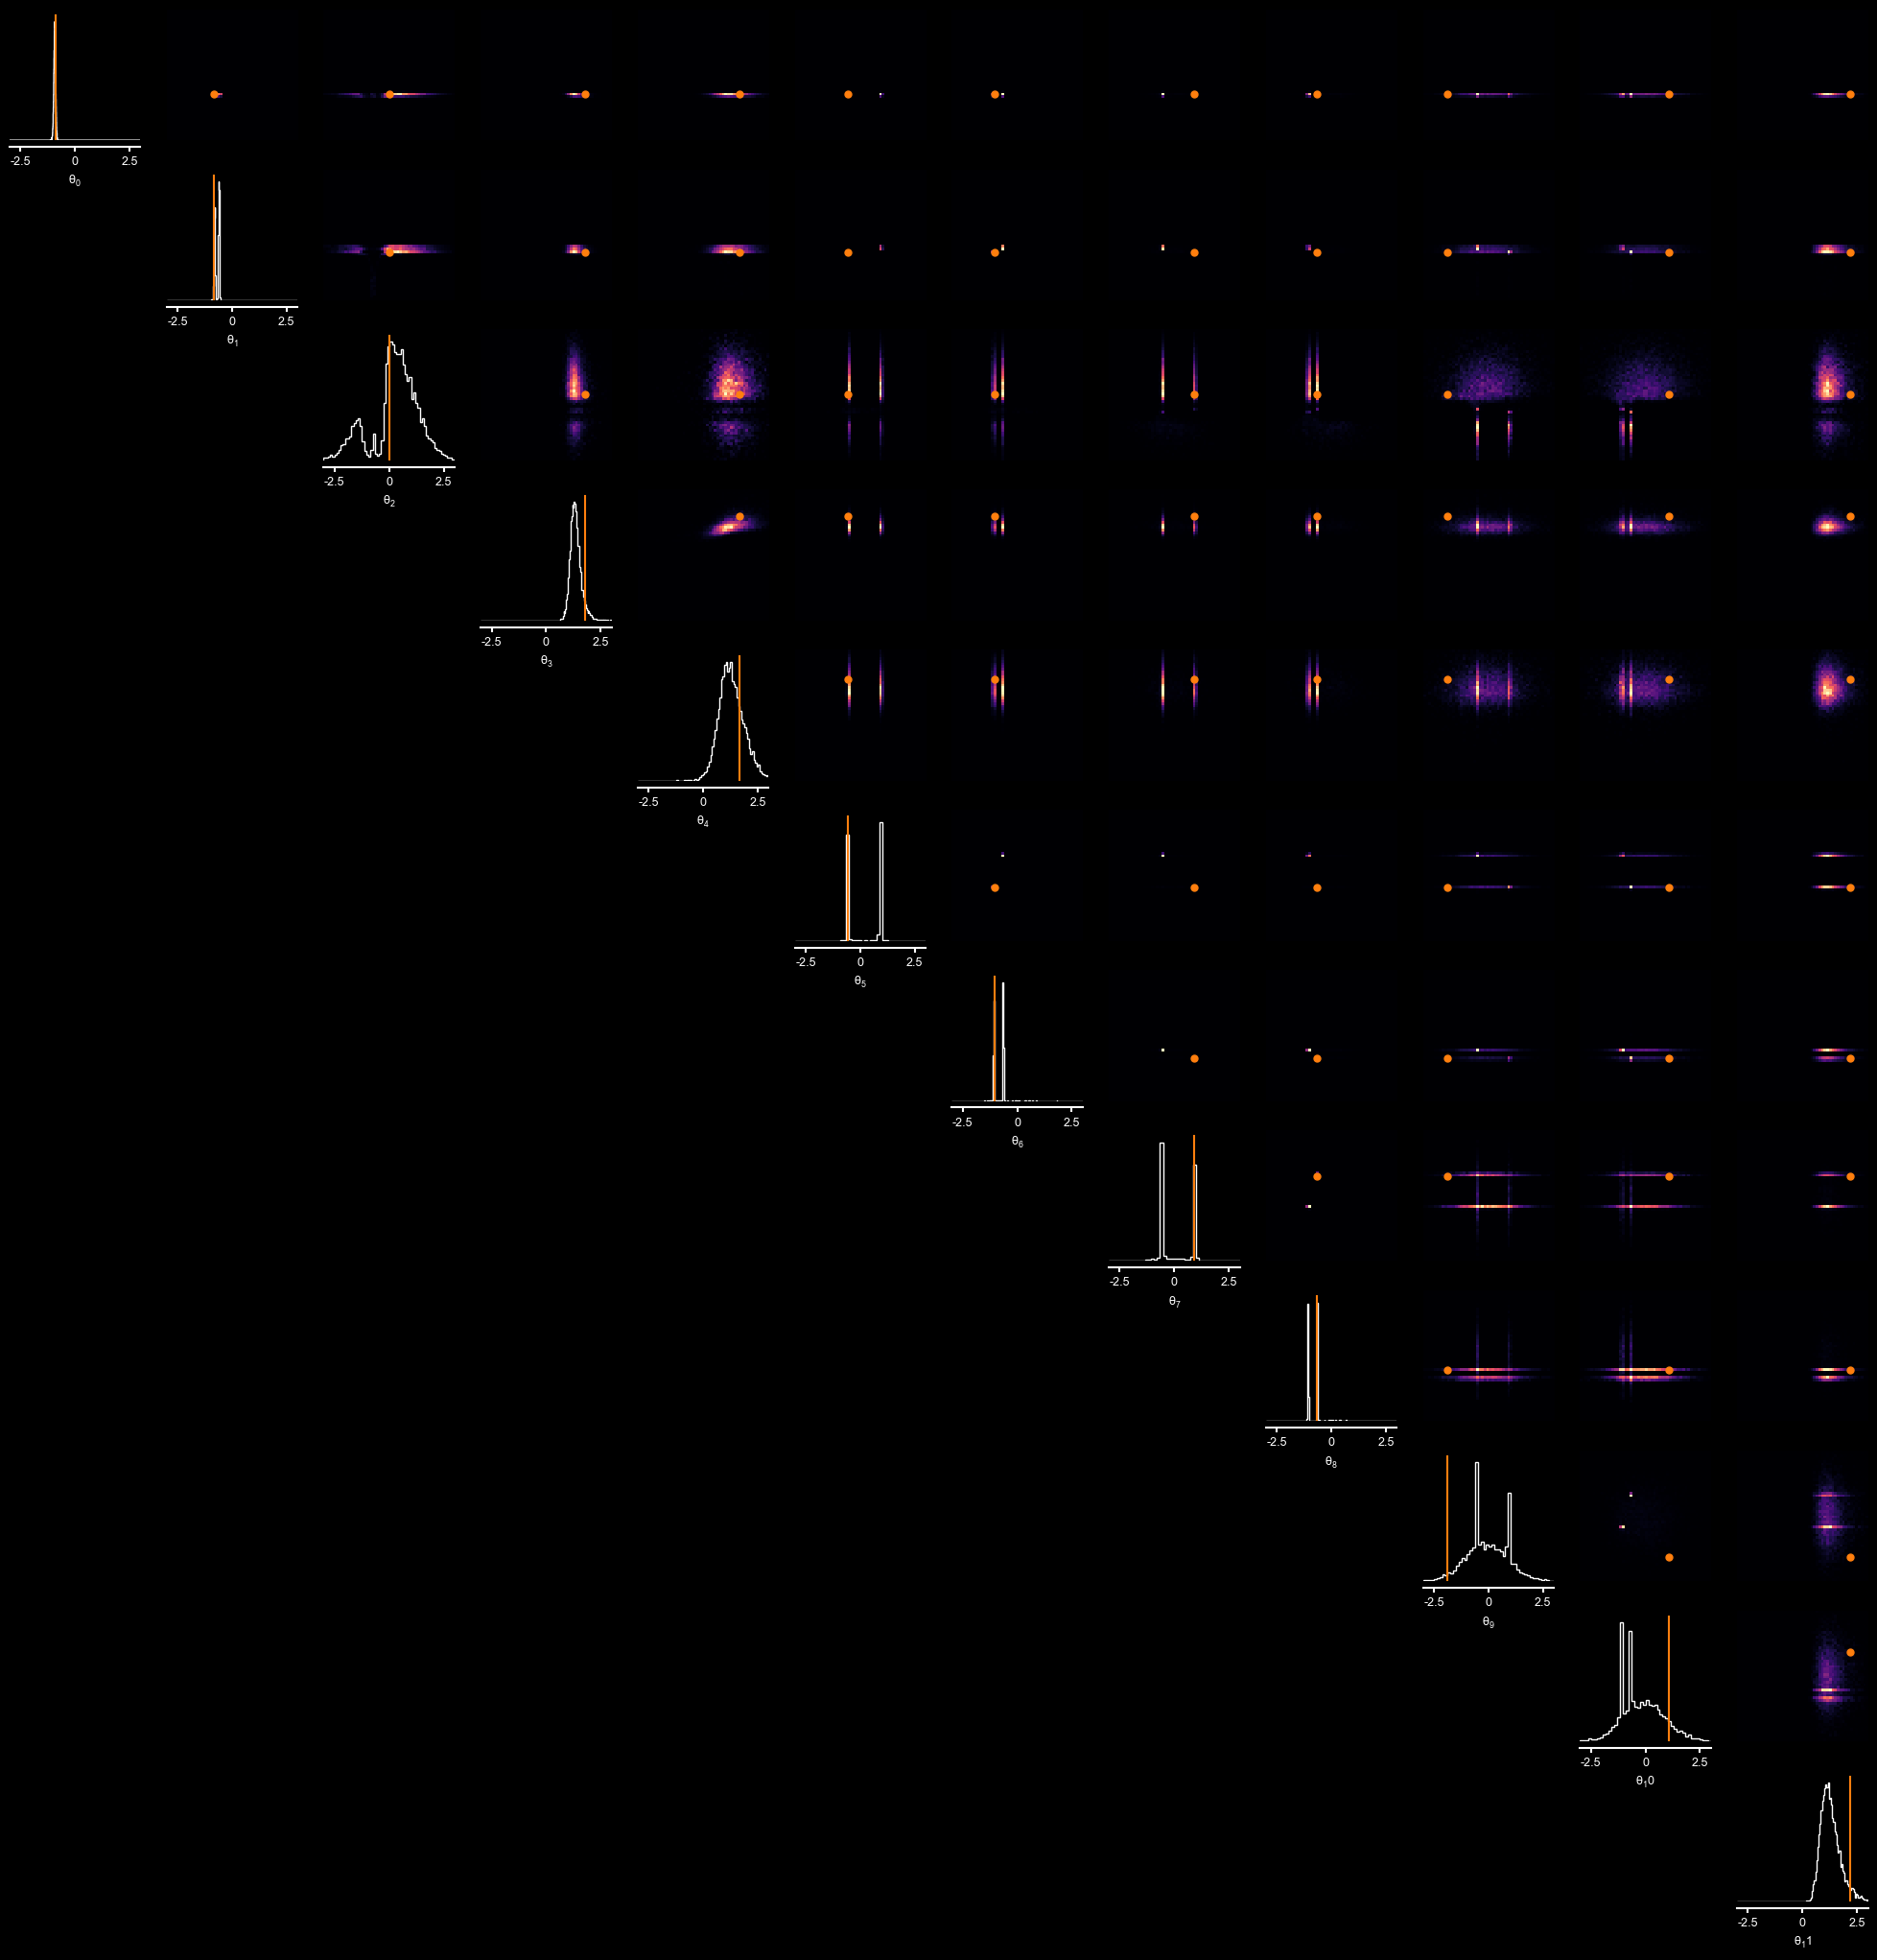

In [25]:
#import sbi
from sbi.analysis.plot import pairplot

_ = pairplot([thetas_post], points=[theta[idx]], limits=[[-3,3]]*20, labels=[f'$\\theta_{i}$' for i in range(20)], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

In [26]:
from blackjax import hmc, tempered_smc,mala
from blackjax.smc.resampling import systematic


In [27]:
acq_single = jax.tree_util.tree_map(lambda x: x[idx], acq)

def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acq_single, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acq_single, x_os[idx])
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)


In [28]:
from blackjax import mala
@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.001, num_integration_steps=10, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        new_state, info = smc.step(rng, state, 1.)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        new_state = new_state._replace(lmbda=0.99)
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 3)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [29]:
particles =smc(thetas_post)

ESS: 9654.0654296875, acc_rate: 0.9982839822769165
ESS: 9820.716796875, acc_rate: 0.9970824122428894
ESS: 9888.9208984375, acc_rate: 0.99586421251297


In [30]:
def sliced_wasserstein_distance(X, Y, num_projections=5000, seed=0):
    # Get shapes and dimensions
    n_X, d_X = X.shape
    n_Y, d_Y = Y.shape

    # Generate random projections
    key = jax.random.key(seed)
    projections = jax.random.normal(key, (num_projections, d_X))
    projections = projections / jnp.linalg.norm(projections, axis=1, keepdims=True)

    # Project the data
    X_proj = jnp.dot(X, projections.T)
    Y_proj = jnp.dot(Y, projections.T)

    # Sort projections
    X_proj = jnp.sort(X_proj, axis=0)
    Y_proj = jnp.sort(Y_proj, axis=0)

    # Calculate distances
    distances = jnp.mean((X_proj - Y_proj) ** 2, axis=0)
    swd = jnp.sqrt(jnp.mean(distances))

    return swd

# Calculate SWD between particles and prior samples
swd = sliced_wasserstein_distance(particles, thetas_post)
print(f"Sliced Wasserstein Distance: {swd}")


Sliced Wasserstein Distance: 0.026319613680243492


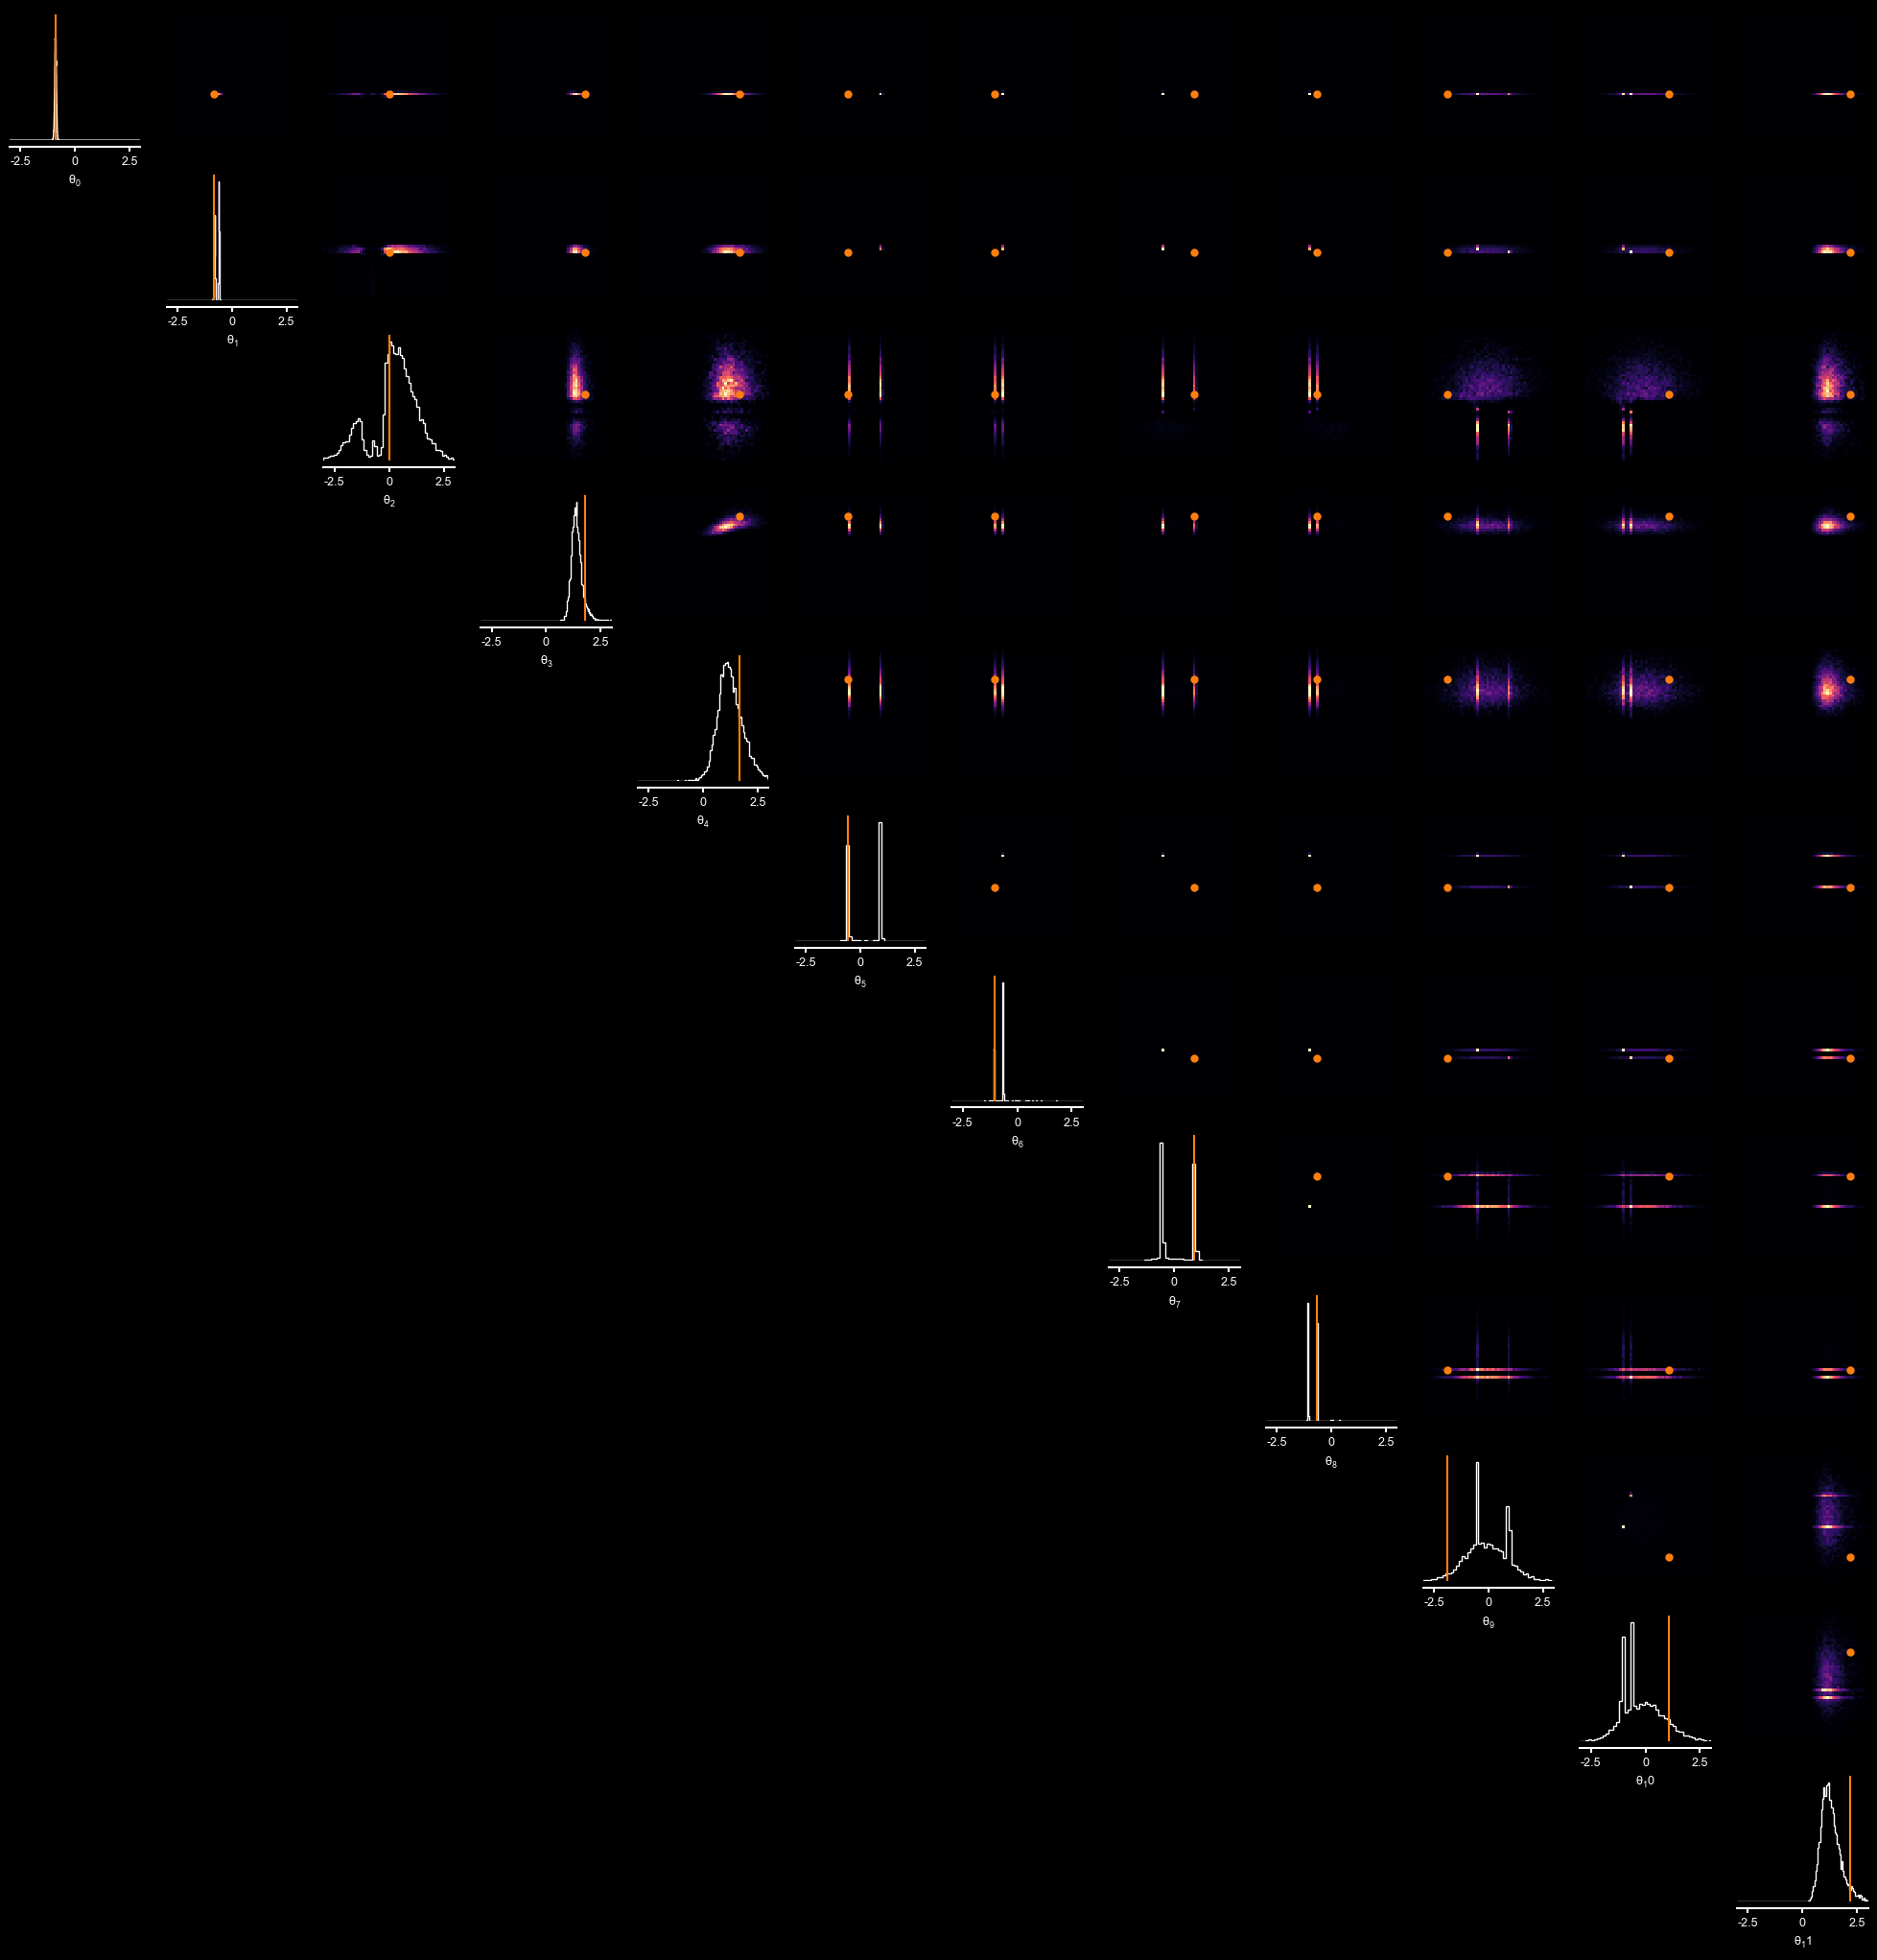

In [31]:
_ = pairplot([particles], points=[theta[idx]], limits=[[-3,3]]*20, labels=[f'$\\theta_{i}$' for i in range(20)], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

Text(0, 0.5, 'MRI Signal')

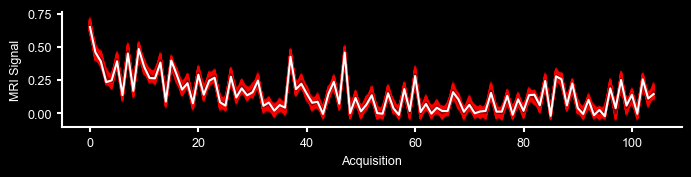

In [32]:

posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 10_000))
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds_sorted[::].T, label="posterior pred", color="red", alpha=0.1)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [33]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=80, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


(-500.0, 331.5287063598633)

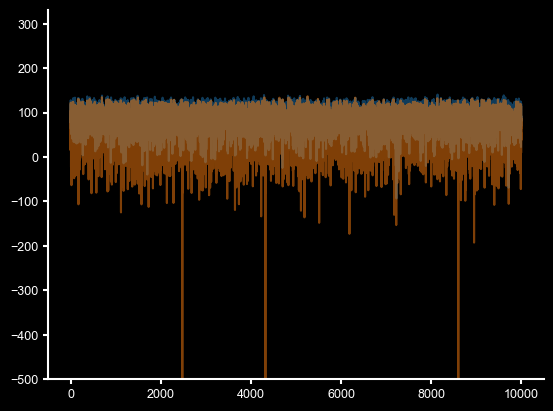

: 

In [34]:
plt.plot(jax.vmap(log_posterior, in_axes=(0,None,None,None))(particles, masks[idx], acq_single, x_os[idx]), alpha=0.5)
plt.plot(jax.vmap(log_posterior, in_axes=(0,None,None,None))(thetas_post, masks[idx], acq_single, x_os[idx]), alpha=0.5)

plt.ylim(-500, None)

In [33]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

folder_name = "data"
data, affine = load_nifti(f"../data/{folder_name}/data.nii.gz")
brain_mask, _ = load_nifti(f"../data/{folder_name}/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs(f"../data/{folder_name}/bvals", f"../data/{folder_name}/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, None)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

In [34]:
np.unique(bvals_rounded)

array([   0., 1000., 2000.])

In [70]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


: 

In [72]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [73]:
exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

In [74]:
acq = acquisition_scheme(np.array(bvals), np.array(bvecs))

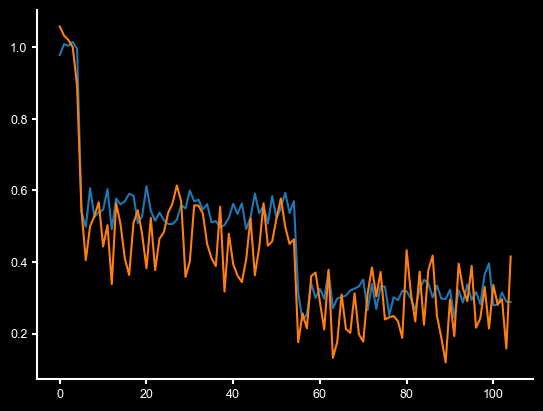

In [76]:
#plt.plot(full_data_flat_in_brain[21_800])
plt.plot(full_data_flat_in_brain[24_800])
#plt.plot(full_data_flat_in_brain[70_000])
# plt.plot(full_data_flat_in_brain[27_800])
# plt.plot(full_data_flat_in_brain[30_800])
# plt.plot(full_data_flat_in_brain[100_000])
# plt.plot(full_data_flat_in_brain[200_000])
plt.plot(full_data_flat_in_brain[100_200])


In [77]:
from functools import partial
#x_o = full_data_flat_in_brain[21_800]
x_o = full_data_flat_in_brain[24_800]
#x_o = full_data_flat_in_brain[70_000]
#x_o = full_data_flat_in_brain[27_800]
# x_o = full_data_flat_in_brain[30_800]
x_o = full_data_flat_in_brain[100_000]
x_o = full_data_flat_in_brain[200_000]
#x_o = full_data_flat_in_brain[100_200]
#model_mask = jnp.ones(5, dtype=jnp.bool)
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)


In [80]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=512, max_noise=80, model_mask=model_mask, sample_method="ode"), in_axes=(0,None, None))(jax.random.split(jax.random.key(0), 10_000), acq, x_o)

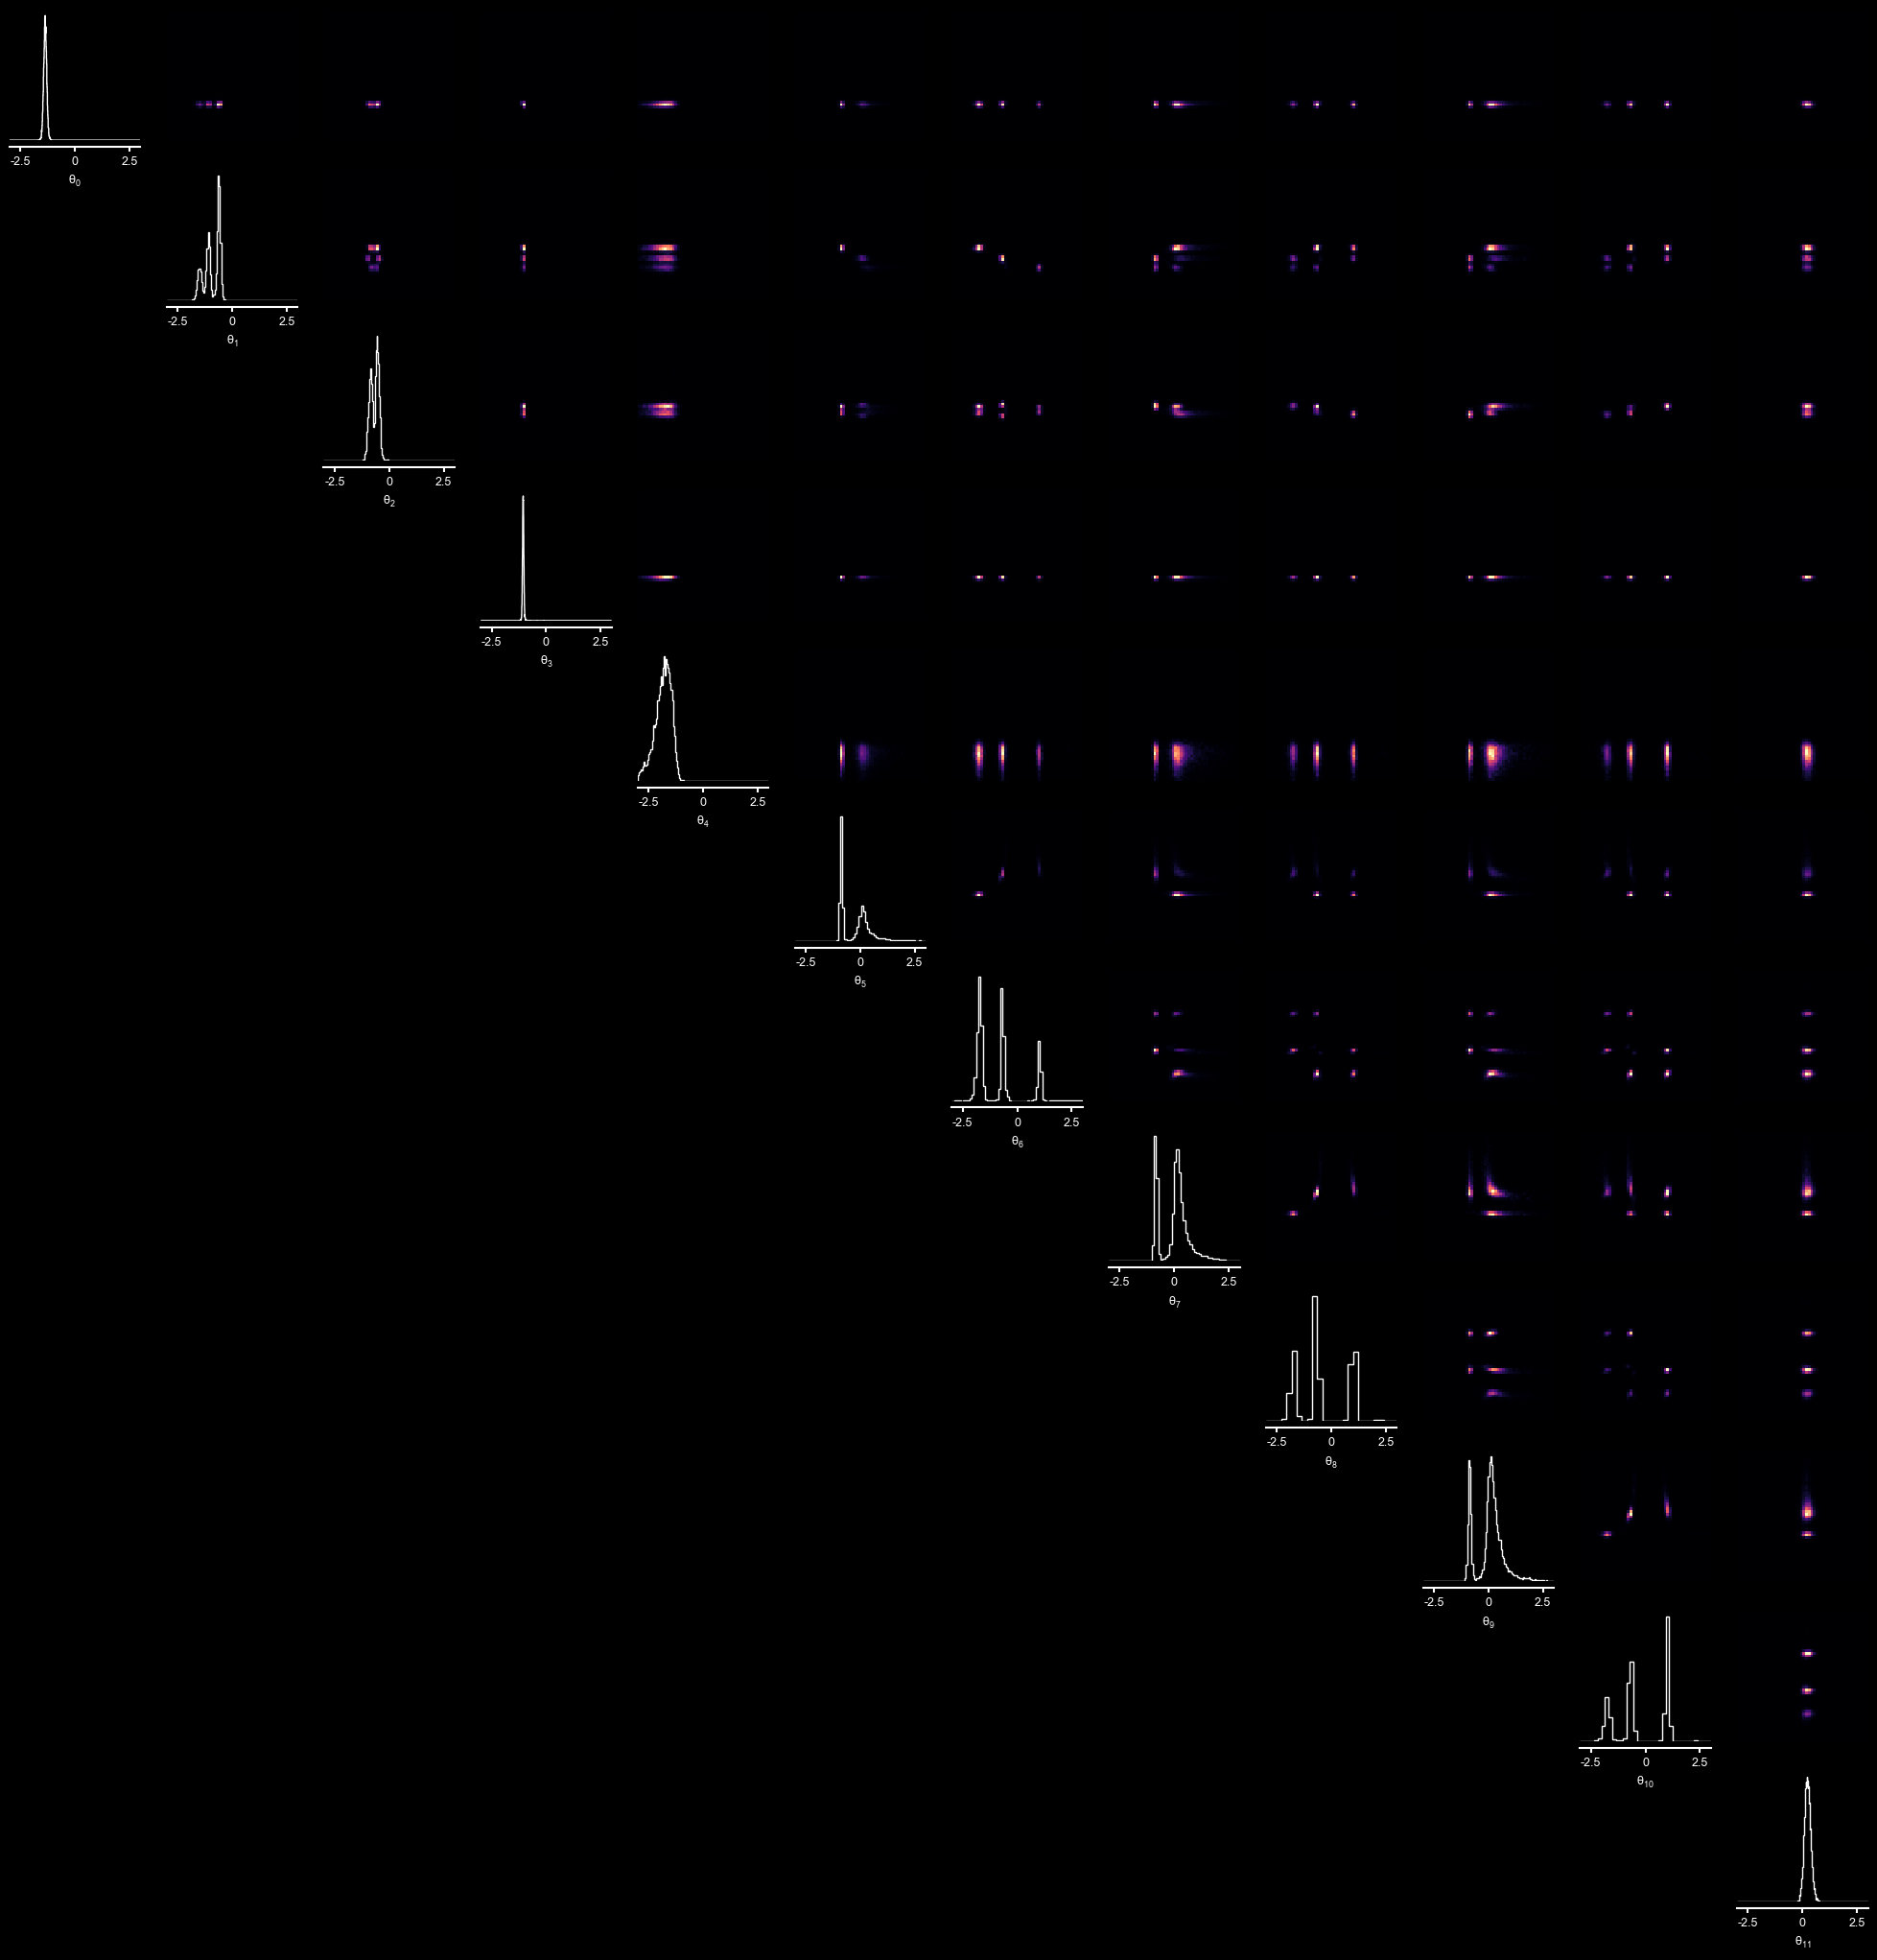

In [81]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot([thetas_post], limits=[[-3,3]]*12, labels=[f'$\\theta_{{{i}}}$' for i in range(12)], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

In [82]:
from functools import partial
from blackjax import hmc, tempered_smc
from blackjax.smc.resampling import systematic

def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals, acq.bvecs), x_o)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)


@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.005, num_integration_steps=20, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        new_state, info = smc.step(rng, state, 1.)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        new_state = new_state._replace(lmbda=0.99)
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [83]:
particles =smc(thetas_post)

ESS: 9770.20703125, acc_rate: 0.9735937118530273
ESS: 9913.2451171875, acc_rate: 0.9636539816856384
ESS: 9950.4521484375, acc_rate: 0.9515936374664307
ESS: 9965.185546875, acc_rate: 0.9454988241195679
ESS: 9973.4609375, acc_rate: 0.9434554576873779


In [84]:
sliced_wasserstein_distance(particles, thetas_post)

Array(0.064, dtype=float32)

Text(0, 0.5, 'MRI Signal')

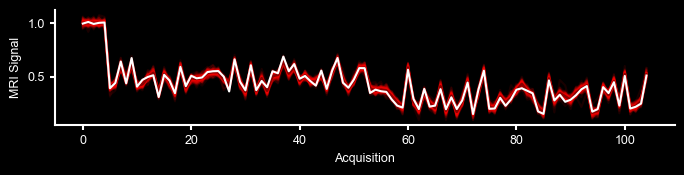

In [85]:
#idx=1000_22
posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 10_000))


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds[::100].T, label="posterior pred", color="red", alpha=0.1)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

#fig.savefig(f"figures_parameter_inference/posterior_pred_idx={idx}.png")

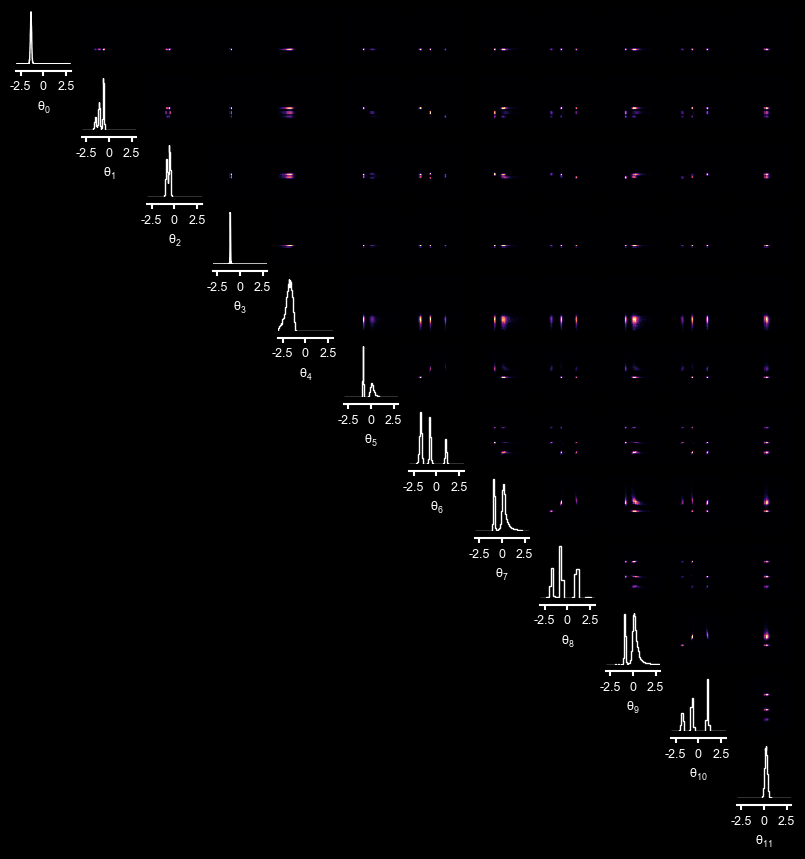

In [86]:
import sbi
from sbi.analysis.plot import pairplot

fig, axes = pairplot([thetas_post], limits=[[-3,3]]*12, labels=[f'$\\theta_{{{i}}}$' for i in range(12)], figsize=(10, 10), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])
#fig.savefig(f"figures_parameter_inference/posterior_particles_idx={idx}.png")

In [87]:

@jax.jit
def estimate_marginal_likelihood_naive(rng,model_mask, x_o):
    n_samples = 100_000_000
    n_batches = 20

    def scan_body(carry, rng):
        thetas = jax.random.normal(rng, (n_samples, 12))
        ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
        # Accumulate log sum exp in the loop
        new_carry = jax.scipy.special.logsumexp(jnp.array([carry, jax.scipy.special.logsumexp(ll)]))
        return new_carry, None

    initial_carry = -jnp.inf  # Initialize with -inf for log sum exp
    final_sum, _ = jax.lax.scan(scan_body, initial_carry, jax.random.split(rng, n_batches))

    N = n_samples * n_batches
    return final_sum - jnp.log(N)

@jax.jit
def estimate_marginal_likelihood(rng,model_mask, x_o):
    n_samples = 20_000
    thetas, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=128, max_noise=80), in_axes=(0,None,None,None,None))(jax.random.split(rng, n_samples), acq.bvals, acq.bvecs, x_o, model_mask)
    prior_probs = jax.scipy.stats.norm.logpdf(thetas, 0, 1).sum(-1)
    logweights = prior_probs - log_probs
    true_ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
    importance_weighted_ll = logweights + true_ll
    return jax.scipy.special.logsumexp(importance_weighted_ll) - jnp.log(n_samples)


def prior_log_prob(model_mask, p):
    N = model_mask.shape[0]
    log_probs = []

    for i in range(N-1):
        if model_mask[i] != 1:
            # If the forced index isn't 1, this component gives zero prob.
            log_probs.append(-jnp.inf)
        else:
            mask_except_i = jnp.concatenate([model_mask[:i], model_mask[i+1:]])
            logpmf_except_i = jax.scipy.stats.bernoulli.logpmf(mask_except_i, p)
            log_prob_i = jnp.sum(logpmf_except_i)
            log_probs.append(log_prob_i)

    return jax.scipy.special.logsumexp(jnp.array(log_probs)) - jnp.log(N)


def estimate_true_mask_posterior(model_mask, ll,p):
    prior = prior_log_prob(model_mask, p)
    return ll + prior


In [154]:
estimate_marginal_likelihood(jax.random.key(0), jnp.array([True, True, False, False, True]), x_o)

Array(335.089, dtype=float32)

In [155]:
estimate_marginal_likelihood(jax.random.key(1), jnp.array([True, True, True, True, True]), x_o)

Array(334.003, dtype=float32)

In [156]:
ll1s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, False, False, True]), x_o) for i in range(2)]
ll2s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, False, True]), x_o) for i in range(2)]
ll3s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, True, True]), x_o) for i in range(2)]


In [42]:
# ll1s = [142.66317749023438, 142.6559295654297, 142.555419921875, 143.3146514892578]
# ll2s = [167.90570068359375, 164.6666717529297, 165.65052795410156, 174.2813720703125]
# ll3s = [169.77635192871094, 166.69369506835938, 170.23654174804688, 168.00157165527344]


# # 142.555419921875
# # 165.65052795410156
# # 170.23654174804688

In [157]:
ps = np.linspace(0,1,100)

In [158]:
prior_probs1 = [prior_log_prob(jnp.array([True, True, False, False, True]), p) for p in ps]
prior_probs2 = [prior_log_prob(jnp.array([True, True, True, False, True]), p) for p in ps]
prior_probs3 = [prior_log_prob(jnp.array([True, True, True, True, True]), p) for p in ps]

prior_probs = np.stack([prior_probs1, prior_probs2, prior_probs3], axis=-1)
prior_probs = jax.nn.softmax(prior_probs, axis=-1)


In [159]:
ps_mc = []
ps_est = []
for p_prior in ps:
    # True posterior
    # First ll estimate
    ps_true_all = []
    for i in range(len(ll1s)):
        p_ball_stick1 = estimate_true_mask_posterior(jnp.array([True, True, False, False, True]), ll1s[i], p_prior)
        p_ball_stick1_stick2 = estimate_true_mask_posterior(jnp.array([True, True, True, False, True]), ll2s[i], p_prior)
        p_ball_s123 = estimate_true_mask_posterior(jnp.array([True, True, True, True, True]), ll3s[i], p_prior)

        ps_true = jnp.stack([p_ball_stick1, p_ball_stick1_stick2, p_ball_s123], axis=-1)
        ps_true = jax.nn.softmax(ps_true, axis=-1)
        ps_true_all.append(ps_true)

    ps_mc.append(ps_true_all)

    # Model estimate
    p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_s123_est = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))

    ps_model = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123_est], axis=-1)
    ps_model = jax.nn.softmax(ps_model, axis=-1)
    ps_est.append(ps_model)


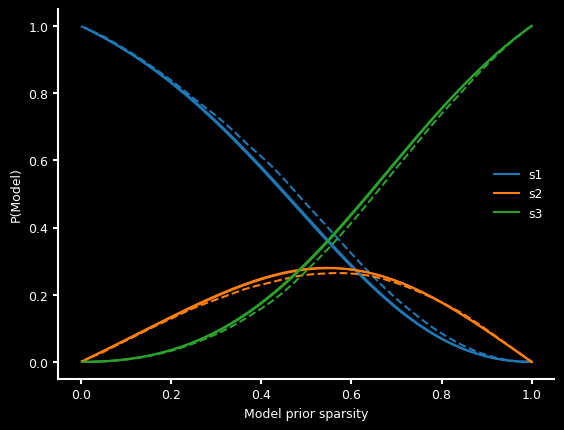

In [161]:
for i, (c1, c2, c3) in enumerate([(0.122, 0.467, 0.706), (1.0, 0.498, 0.055), (0.173, 0.627, 0.173)]):
    _ = plt.plot(ps, np.stack([p[0] for p in ps_mc])[:,i], color=(c1, c2, c3))
    _ = plt.plot(ps, np.stack([p[1] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[2] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[3] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[4] for p in ps_mc])[:,i], color=(c1, c2, c3))
    _ = plt.plot(ps, np.stack(ps_est)[:,i], '--', color=(c1, c2, c3))

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])

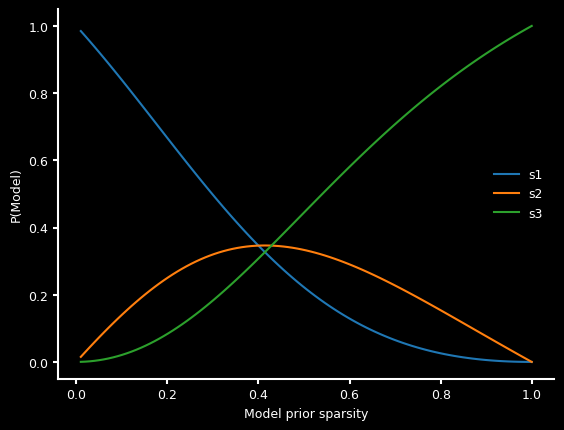

In [162]:

_ = plt.plot(ps, prior_probs[:,0], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, prior_probs[:,1], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, prior_probs[:,2], color=(0.173, 0.627, 0.173))

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])

In [47]:
# Estiamte by model
p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
p_ball_s123 =  model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))


ps_est = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123], axis=-1)
ps_est = jax.nn.softmax(ps_est, axis=-1)
ps_est


Array([0.   , 0.358, 0.642], dtype=float32)

In [30]:
from blackjax import hmc, tempered_smc
from blackjax.smc.resampling import systematic
from functools import partial
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

def log_likelihood_fn(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def posterior_pred(theta, rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def smc(rng,thetas,model_mask, acq, x_o):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.005, num_integration_steps=2, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic
    _log_likelihood_fn = partial(log_likelihood_fn, mask=model_mask, acq=acq, x=x_o)
    smc = tempered_smc(log_prior_fn, _log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state =state._replace(lmbda=0.99)
        new_state, info = smc.step(rng, state, 1.)
        return new_state, info

    rng_keys = jax.random.split(rng, 3)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles, final_state.weights


def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    K = 50
    propose_fn = partial(model.sample_theta, num_steps=32, max_noise=80)
    key_k = jax.random.split(key, K)
    theta = jax.vmap(propose_fn, in_axes=(0,None,None,None, None))(key_k, acq.bvals, acq.bvecs, x,model_mask)
    theta_corr, weights = smc(subkey, theta, model_mask, acq, x)
    # theta_corr = theta
    # weights = None
    return theta_corr, weights

sample_theta_per_x = jax.jit(jax.vmap(sample_mcmc_correct))

In [24]:
full_data_flat_in_brain.shape[0] / 6

37973.333333333336

In [29]:
thetas_corr, weights = sample_theta_per_x(jax.random.split(jax.random.key(0), 38000), full_data_flat_in_brain[1000:39000])

In [26]:
jnp.mean(1/jnp.sum(weights**2,-1))

Array(49.6, dtype=float32)

In [194]:
xs_pred = jax.vmap(jax.vmap(posterior_pred, in_axes=(0,None)))(thetas_corr, jax.random.split(jax.random.key(0), 20000))

In [195]:
xs_pred

(20000, 50, 105)

In [197]:
(xs_pred.mean(1) - full_data_flat_in_brain[1000:21000]).mean(0)

Array([-0.021, -0.008,  0.011,  0.007,  0.014, -0.021, -0.015, -0.017,
       -0.013, -0.016, -0.012, -0.01 , -0.016, -0.018, -0.011, -0.018,
       -0.013, -0.012, -0.013, -0.008, -0.009, -0.011, -0.011, -0.013,
       -0.015, -0.01 , -0.018, -0.015, -0.014, -0.013, -0.014, -0.018,
       -0.011, -0.01 , -0.005, -0.01 , -0.014, -0.006, -0.012, -0.011,
       -0.013, -0.01 , -0.011, -0.007, -0.012, -0.01 , -0.007, -0.009,
       -0.009, -0.011, -0.011, -0.014, -0.01 , -0.01 , -0.017, -0.027,
       -0.031, -0.033, -0.032, -0.032, -0.031, -0.027, -0.028, -0.034,
       -0.028, -0.027, -0.028, -0.031, -0.028, -0.029, -0.031, -0.028,
       -0.03 , -0.032, -0.029, -0.027, -0.028, -0.027, -0.027, -0.025,
       -0.029, -0.031, -0.031, -0.031, -0.032, -0.027, -0.03 , -0.028,
       -0.026, -0.025, -0.023, -0.026, -0.026, -0.031, -0.028, -0.031,
       -0.027, -0.029, -0.029, -0.025, -0.027, -0.024, -0.029, -0.027,
       -0.023], dtype=float32)

In [181]:
thetas_corr.sum()

Array(nan, dtype=float32)

In [198]:

#sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 20_000
key = jax.random.key(0)
thetas_full = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = np.array(batch_thetas)
    thetas_full.append(batch_thetas)
    #print(ess.mean())
thetas_full = np.concatenate(thetas_full, axis=0)


Batch 0
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


KeyboardInterrupt: 

In [530]:
# Sample masks whole brain

def sample_mask_per_x(key, x):
    keys = jax.random.split(key, 500)
    return jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(keys, acq.bvals, acq.bvecs, x, jnp.array([0.1]))

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


In [531]:
jax.clear_caches()

In [532]:


batch_size = 1_000
key = jax.random.key(0)
masks_brain = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    masks_brain.append(batch_masks)
masks_brain = np.concatenate(masks_brain, axis=0)


Batch 0
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Batch 16000
Batch 17000
Batch 18000
Batch 19000
Batch 20000
Batch 21000
Batch 22000
Batch 23000
Batch 24000
Batch 25000
Batch 26000
Batch 27000
Batch 28000
Batch 29000
Batch 30000
Batch 31000
Batch 32000
Batch 33000
Batch 34000
Batch 35000
Batch 36000
Batch 37000
Batch 38000
Batch 39000
Batch 40000
Batch 41000
Batch 42000
Batch 43000
Batch 44000
Batch 45000
Batch 46000
Batch 47000
Batch 48000
Batch 49000
Batch 50000
Batch 51000
Batch 52000
Batch 53000
Batch 54000
Batch 55000
Batch 56000
Batch 57000
Batch 58000
Batch 59000
Batch 60000
Batch 61000
Batch 62000
Batch 63000
Batch 64000
Batch 65000
Batch 66000
Batch 67000
Batch 68000
Batch 69000
Batch 70000
Batch 71000
Batch 72000
Batch 73000
Batch 74000
Batch 75000
Batch 76000
Batch 77000
Batch 78000
Batch 79000
Batch 80000
Batch 81000
Batch 82000
Batch 83000
Batch

In [533]:
full_data_flat.shape

(778752, 105)

In [534]:
ball = jnp.array([True, False, False, False, True])
ball_stick1 = jnp.array([True, True, False, False, True])
ball_stick2 = jnp.array([True, False, True, False, True])
ball_stick3 = jnp.array([True, False, False, True, True])

ball_stick1_stick2 = jnp.array([True, True, True, False, True])
ball_stick1_stick3 = jnp.array([True, True, False, True, True])
ball_stick2_stick3 = jnp.array([True, False, True, True, True])

ball_stick1_stick2_stick3 = jnp.array([True, True, True, True, True])

p_ball = (masks_brain == ball).all(-1).mean(1)

p_ball_stick1 = (masks_brain == ball_stick1).all(-1).mean(1)
p_ball_stick2 = (masks_brain == ball_stick2).all(-1).mean(1)
p_ball_stick3 = (masks_brain == ball_stick3).all(-1).mean(1)

p_ball_stick1_stick2 = (masks_brain == ball_stick1_stick2).all(-1).mean(1)
p_ball_stick1_stick3 = (masks_brain == ball_stick1_stick3).all(-1).mean(1)
p_ball_stick2_stick3 = (masks_brain == ball_stick2_stick3).all(-1).mean(1)

p_ball_stick1_stick2_stick3 = (masks_brain == ball_stick1_stick2_stick3).all(-1).mean(1)

p_sim_configs = jnp.stack([p_ball, p_ball_stick1, p_ball_stick2, p_ball_stick3, p_ball_stick1_stick2, p_ball_stick1_stick3, p_ball_stick2_stick3, p_ball_stick1_stick2_stick3], axis=-1)
p_sim_configs = p_sim_configs / (p_sim_configs.sum(-1, keepdims=True) + 1e-10)

In [582]:
p_sim_configs.mean(0)

Array([0.038, 0.045, 0.033, 0.04 , 0.152, 0.067, 0.056, 0.568], dtype=float32)

: 

In [536]:
best_model = p_sim_configs.argmax(1)

In [537]:
marginal_probs = masks_brain.mean(1)
full_brain_marginal_probs = np.zeros((full_data_flat.shape[0], 5))
full_brain_marginal_probs[brain_mask_flat.astype(np.bool),...] = marginal_probs
full_brain_marginal_probs = full_brain_marginal_probs.reshape(data_norm.shape[:-1] + (5,))

In [538]:
full_p_sim_configs = np.zeros((full_data_flat.shape[0], 8))
full_p_sim_configs[brain_mask_flat.astype(np.bool),...] = p_sim_configs
full_p_sim_configs = full_p_sim_configs.reshape(data_norm.shape[:-1] + (8,))

In [539]:
full_best_model = np.zeros(full_data_flat.shape[0])
full_best_model[brain_mask_flat.astype(np.bool)] = best_model
full_best_model = full_best_model.reshape(data_norm.shape[:-1])

In [540]:
p_sim_configs.shape

(227840, 8)

In [543]:
np.quantile(marginal_probs[...,3], (0.05, 0.5,0.95))

array([0.202, 0.892, 1.   ])

In [544]:
p_sim_1stick = p_sim_configs[...,1:4].sum(-1)
p_sim_2stick = p_sim_configs[...,4:7].sum(-1)
p_sim_3stick = p_sim_configs[...,7:8].sum(-1)
p_stick_configs = jnp.stack([p_sim_1stick, p_sim_2stick, p_sim_3stick], axis=-1)
full_p_stick_configs = np.zeros((full_data_flat.shape[0], 3))
full_p_stick_configs[brain_mask_flat.astype(np.bool),...] = p_stick_configs
full_p_stick_configs = full_p_stick_configs.reshape(data_norm.shape[:-1] + (3,))


In [581]:
p_stick_configs.mean(0) / p_stick_configs.mean(0).sum()

Array([0.123, 0.286, 0.591], dtype=float32)

<OrthoSlicer3D: (104, 104, 72)>

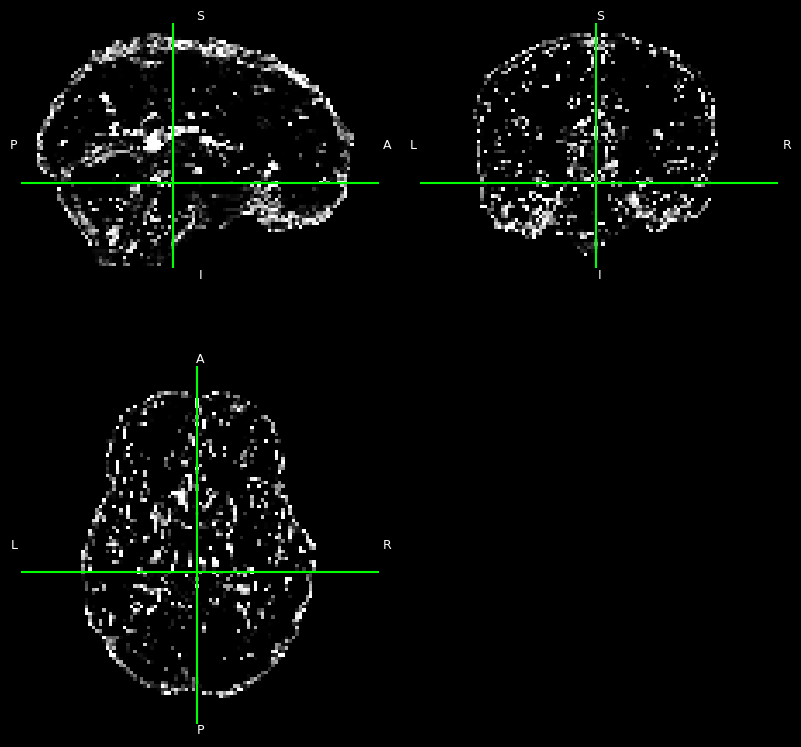

In [555]:
%matplotlib inline
import nibabel as nb
nb.Nifti1Image(full_p_stick_configs[...,0], affine).orthoview()